In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (mean_absolute_error,mean_squared_error)

df = pd.read_csv("../data/processed/processed_data.csv")

df["Date"] = pd.to_datetime(df["Date"])



# SARIMA USING statsforecast

In [2]:
pip install statsforecast

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

In [4]:
df_new= df.dropna().copy()


In [5]:
df_new.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Temperature,Fuel_Price,...,Lag_2,Lag_4,Lag_8,Lag_52,Sales_Roll_Mean_4,Sales_Roll_Std_4,Sales_Roll_Mean_12,Sales_Roll_Std_12,Sales_EMA_4,Sales_EMA_12
52,1,1,2011-02-04,21665.76,0,2011,2,5,42.27,2.989,...,17341.47,15984.24,31497.65,24924.50,17286.6475,1013.925386,25087.749167,12701.860945,19720.954335,23775.964205
53,1,1,2011-02-11,37887.17,1,2011,2,6,36.39,3.022,...,18461.18,17359.70,44912.86,46039.49,18707.0275,2040.798674,25264.113333,12632.473744,20498.876601,23451.317404
54,1,1,2011-02-18,46845.87,0,2011,2,7,57.36,3.045,...,21665.76,17341.47,55931.23,41595.55,23838.8950,9543.110891,26791.974167,12982.799578,27454.193961,25672.217804
55,1,1,2011-02-25,19363.83,0,2011,2,8,62.90,3.065,...,37887.17,18461.18,19124.58,19403.54,31214.9950,13449.781394,29127.439167,13906.316950,35210.864376,28929.702757
56,1,1,2011-03-04,20327.61,0,2011,3,9,59.58,3.288,...,46845.87,21665.76,15984.24,21827.90,31440.6575,13169.111324,28864.628333,14071.411666,28872.050626,27458.030025


In [6]:
df_new.shape

(261083, 32)

In [7]:
df_new = df_new.rename(columns={"Store":"store","Dept":"dept","Date":"ds","Weekly_Sales":"y"})

In [8]:
df_new["unique_id"] = (df_new["store"].astype(str)+ "_"+ df_new["dept"].astype(str))


In [9]:
df_new = df_new[["unique_id","ds","y"]]
df_new.head()

,unique_id,ds,y
52,1_1,2011-02-04,21665.76
53,1_1,2011-02-11,37887.17
54,1_1,2011-02-18,46845.87
55,1_1,2011-02-25,19363.83
56,1_1,2011-03-04,20327.61


In [10]:
split_date = "2012-03-01"

train = df_new[df_new.ds <= split_date]

valid = df_new[df_new.ds > split_date]

In [11]:
sf = StatsForecast(models=[AutoARIMA(season_length=52)],freq="W-FRI",n_jobs=-1)

In [12]:
sf.fit(train)

StatsForecast(models=[AutoARIMA])

In [13]:
h = valid["ds"].nunique()

In [14]:
forecast = sf.predict(h=h)
forecast.head()

,unique_id,ds,AutoARIMA
0,10_1,2012-03-02,18191.244986
1,10_1,2012-03-09,40795.608583
2,10_1,2012-03-16,40795.608583
3,10_1,2012-03-23,40795.608583
4,10_1,2012-03-30,40795.608583


In [15]:
results = valid.merge(forecast,on=["unique_id","ds"])
print(results)

       unique_id         ds         y     AutoARIMA
0            1_1 2012-03-02  20113.03   6979.454825
1            1_1 2012-03-09  21140.07  23084.869233
2            1_1 2012-03-16  22366.88  23084.869233
3            1_1 2012-03-23  22107.70  23084.869233
4            1_1 2012-03-30  28952.86  23084.869233
...          ...        ...       ...           ...
100735     45_98 2012-09-28    508.37    750.502580
100736     45_98 2012-10-05    628.10    750.502580
100737     45_98 2012-10-12   1061.02    750.502580
100738     45_98 2012-10-19    760.01    750.502580
100739     45_98 2012-10-26   1076.80    750.502580

[100740 rows x 4 columns]


In [16]:
mae = np.mean(np.abs(results["y"] -results["AutoARIMA"]))
print(mae)

2713.7719888779257


In [17]:
rmse = np.sqrt(np.mean((results["y"]-results["AutoARIMA"])**2))
print(rmse)

5992.584875339259


In [18]:
wmape = (np.abs(results["y"]-results["AutoARIMA"]).sum()/np.abs(results["y"]).sum())*100
print(wmape)
print("Accuracy:",100-wmape)

16.68454025700337
Accuracy: 83.31545974299664


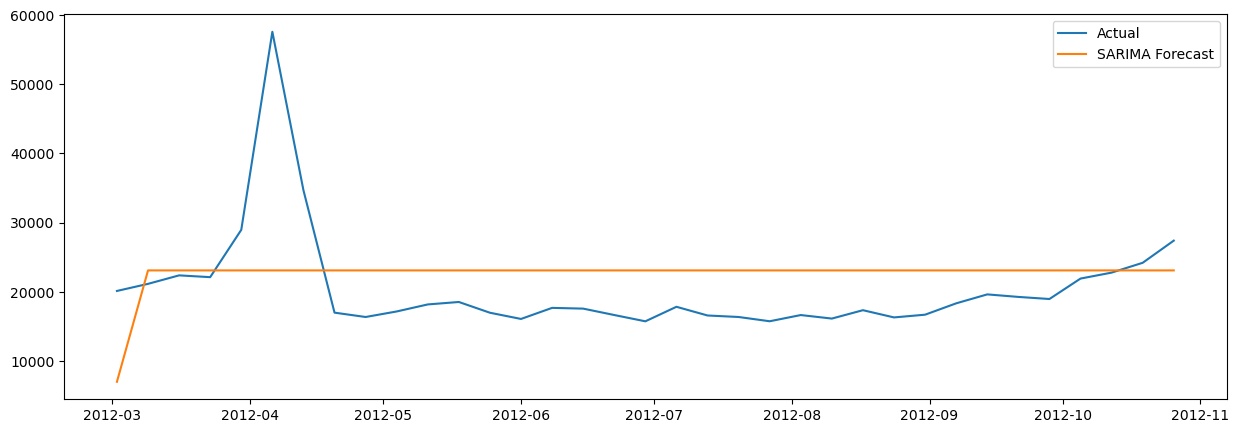

In [19]:
sample = "1_1"

actual = results[
    results["unique_id"] == sample
]

plt.figure(figsize=(15,5))

plt.plot(
    actual["ds"],
    actual["y"],
    label="Actual"
)

plt.plot(
    actual["ds"],
    actual["AutoARIMA"],
    label="SARIMA Forecast"
)

plt.legend()

plt.show()